In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
# metadata with moa
full_meta = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/metadata/full_meta.csv")
full_meta.head(3)

,Unnamed: 0,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,Image_Metadata_Plate_DAPI,Image_Metadata_Well_DAPI,Replicate,Image_Metadata_Compound,Image_Metadata_Concentration,compound,concentration,moa
0,0,1,11,Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-...,Week1/Week1_22123,Week1_150607_B04_s3_w2D81AEFB9-9DD4-4B59-9177-...,Week1/Week1_22123,Week1_150607_B04_s3_w408BE006A-BF34-457E-81A9-...,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,cytochalasin B,10.0,Actin disruptors
1,1,1,12,Week1_150607_B04_s4_w1EB720AD1-83BA-48A7-8C47-...,Week1/Week1_22123,Week1_150607_B04_s4_w261B79A05-7534-46F3-8C80-...,Week1/Week1_22123,Week1_150607_B04_s4_w49FF7E7B1-F049-4994-BCA2-...,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,cytochalasin B,10.0,Actin disruptors
2,2,1,9,Week1_150607_B04_s1_w11323931B-BDA7-4F42-870E-...,Week1/Week1_22123,Week1_150607_B04_s1_w2F8F7EA7A-EC57-49CA-A556-...,Week1/Week1_22123,Week1_150607_B04_s1_w494DCA5C4-3531-497D-A8B0-...,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,cytochalasin B,10.0,Actin disruptors


In [5]:
#column clean-up
full_meta = full_meta.drop(columns=["compound", "concentration"])

full_meta = full_meta.rename(columns={
    "Image_Metadata_Compound": "compound",
    "Image_Metadata_Concentration": "concentration",
    "Image_Metadata_Plate_DAPI": "plate",
    "Image_Metadata_Well_DAPI": "well"
})

full_meta.columns

Index(['Unnamed: 0', 'TableNumber', 'ImageNumber', 'Image_FileName_DAPI',
       'Image_PathName_DAPI', 'Image_FileName_Tubulin',
       'Image_PathName_Tubulin', 'Image_FileName_Actin',
       'Image_PathName_Actin', 'plate', 'well', 'Replicate', 'compound',
       'concentration', 'moa'],
      dtype='object')

In [6]:
#Basic sanity check
print("Total rows:", len(full_meta))
print("Unique compounds:", full_meta["compound"].nunique())
print("Unique MOAs:", full_meta["moa"].nunique())
print(full_meta["moa"].value_counts())

Total rows: 516
Unique compounds: 8
Unique MOAs: 5
moa
Microtubule stabilizers      216
DMSO                         144
Aurora kinase inhibitors      72
Actin disruptors              48
Microtubule destabilizers     36
Name: count, dtype: int64


In [7]:
full_meta.duplicated().sum() #any duplicates

np.int64(0)

In [8]:
#replacing this with the previous data
full_meta.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/processed/metadata_with_moa.csv",
    index=False
)

In [9]:
metadata_with_moa = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/processed/metadata_with_moa.csv")
metadata_with_moa.head(3)

,Unnamed: 0,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,plate,well,Replicate,compound,concentration,moa
0,0,1,11,Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-...,Week1/Week1_22123,Week1_150607_B04_s3_w2D81AEFB9-9DD4-4B59-9177-...,Week1/Week1_22123,Week1_150607_B04_s3_w408BE006A-BF34-457E-81A9-...,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
1,1,1,12,Week1_150607_B04_s4_w1EB720AD1-83BA-48A7-8C47-...,Week1/Week1_22123,Week1_150607_B04_s4_w261B79A05-7534-46F3-8C80-...,Week1/Week1_22123,Week1_150607_B04_s4_w49FF7E7B1-F049-4994-BCA2-...,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
2,2,1,9,Week1_150607_B04_s1_w11323931B-BDA7-4F42-870E-...,Week1/Week1_22123,Week1_150607_B04_s1_w2F8F7EA7A-EC57-49CA-A556-...,Week1/Week1_22123,Week1_150607_B04_s1_w494DCA5C4-3531-497D-A8B0-...,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors


In [ ]:
#replacing this with the previous data
full_meta.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/processed/metadata_with_moa.csv",
    index=False
)

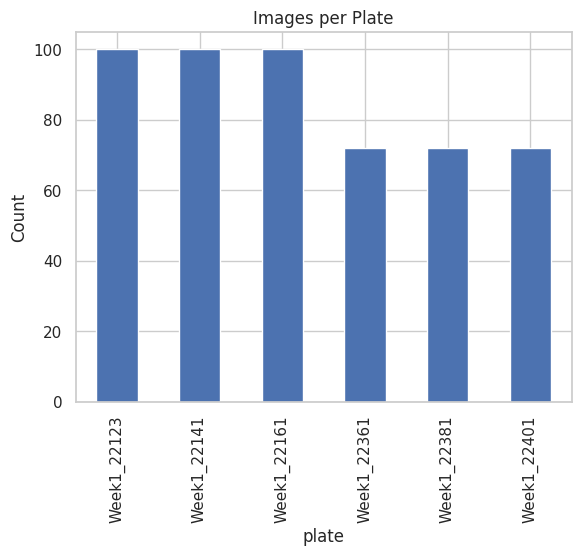

In [10]:
#Plate and well coverage
metadata_with_moa["plate"].value_counts().plot(kind="bar")
plt.title("Images per Plate")
plt.ylabel("Count")
plt.show()

In [11]:
#Missing MOa
missing = metadata_with_moa[metadata_with_moa["moa"].isna()]

print("Images without MOA:", len(missing))
missing["compound"].value_counts().head(10)

Images without MOA: 0


,count
compound,


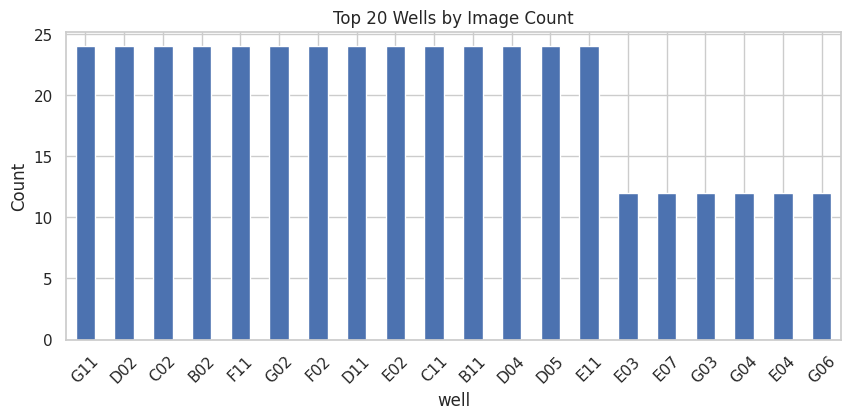

In [12]:
metadata_with_moa["well"].value_counts().head(20).plot(kind="bar", figsize=(10,4))
plt.title("Top 20 Wells by Image Count")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Step 1: Compound vs MOA mapping

In [13]:
metadata_with_moa.columns

Index(['Unnamed: 0', 'TableNumber', 'ImageNumber', 'Image_FileName_DAPI',
       'Image_PathName_DAPI', 'Image_FileName_Tubulin',
       'Image_PathName_Tubulin', 'Image_FileName_Actin',
       'Image_PathName_Actin', 'plate', 'well', 'Replicate', 'compound',
       'concentration', 'moa'],
      dtype='object')

In [14]:
metadata_with_moa[['compound','moa']].drop_duplicates().value_counts() #So that each compund maps to a consistent MOA
# how many compounds per MOA class

,,count
compound,moa,
AZ-A,Aurora kinase inhibitors,1
DMSO,DMSO,1
colchicine,Microtubule destabilizers,1
cytochalasin B,Actin disruptors,1
epothilone B,Microtubule stabilizers,1
latrunculin B,Actin disruptors,1
nocodazole,Microtubule destabilizers,1
taxol,Microtubule stabilizers,1


conclusion:
No compound appears with multiple MOAs

Step 2: Plates & batch effects

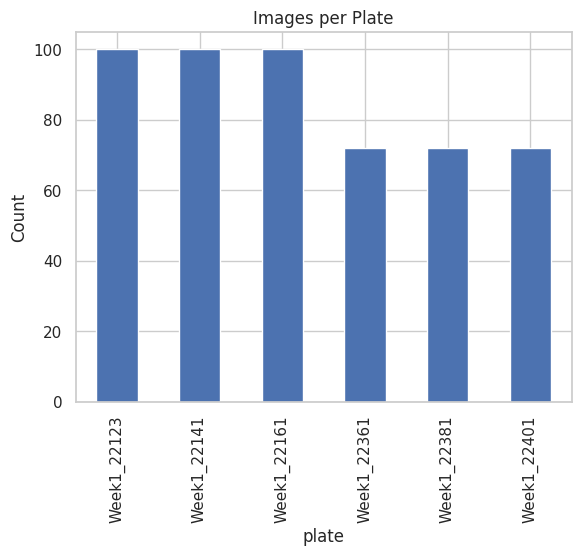

In [15]:
metadata_with_moa['plate'].value_counts().plot(kind='bar') #UMAP later colored by plate (important for batch bias).
plt.title("Images per Plate")
plt.ylabel("Count")
plt.show()

Step 3: Concentration vs MOA

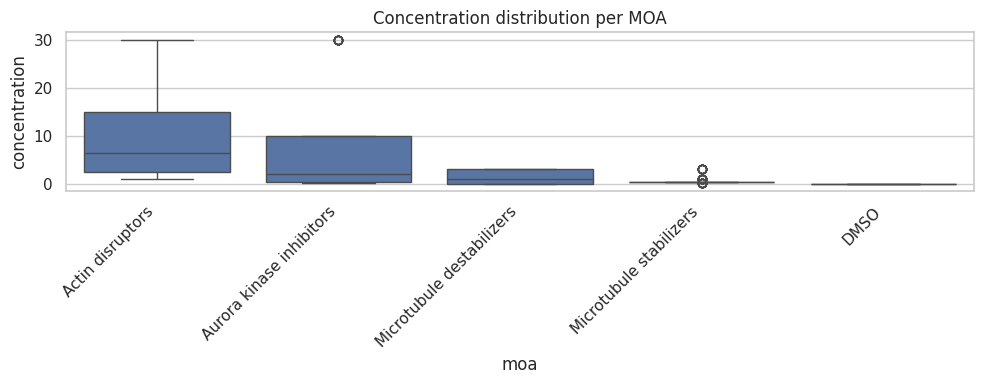

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.boxplot(data=metadata_with_moa, x='moa', y='concentration')
plt.xticks(rotation=45, ha='right')
plt.title("Concentration distribution per MOA")
plt.tight_layout()
plt.show()

Conclucion : some MOAs only present at high or low doses

Step 4: Replicate counts

In [17]:
rep_counts =  metadata_with_moa.groupby(['compound','concentration']).size()
rep_counts.describe()

,0
count,20.000000
mean,25.800000
std,42.520088
min,12.000000
25%,12.000000
50%,12.000000
75%,12.000000
max,156.000000


Text(0, 0.5, 'Frequency')

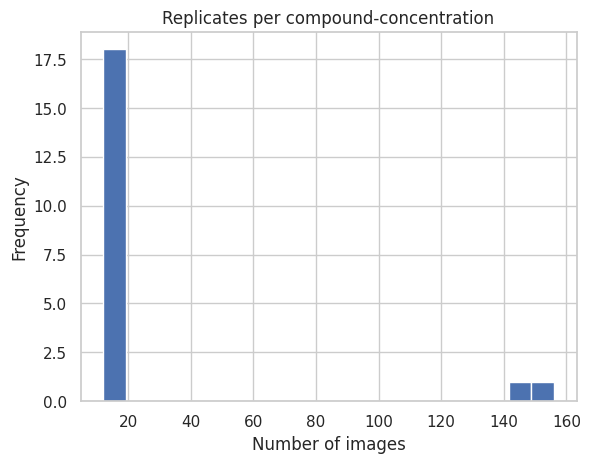

In [18]:
rep_counts.plot(kind='hist', bins=20, title="Replicates per compound-concentration")
plt.xlabel("Number of images")
plt.ylabel("Frequency")

Conclusion:

We have 20 unique (compound, concentration) conditions

Most conditions have 12 replicates



Outlier :“Most compound–concentration conditions have approximately 12 replicate images, reflecting the experimental design. A small number of treatments are overrepresented with more than 70 replicates, likely due to repeated measurements across plates. This imbalance motivates aggregating features per treatment and using compound-level cross-validation in downstream analysis.”

In [24]:
rep_counts.sort_values(ascending=False).head(20)

compound        concentration
taxol           0.30             156
DMSO            0.00             144
AZ-A            0.10              12
                0.30              12
                3.00              12
                1.00              12
                30.00             12
                10.00             12
cytochalasin B  10.00             12
                30.00             12
epothilone B    0.10              12
colchicine      0.03              12
epothilone B    0.30              12
                1.00              12
latrunculin B   3.00              12
                1.00              12
nocodazole      1.00              12
                3.00              12
taxol           1.00              12
                3.00              12
dtype: int64

Connclusion :

1. Taxol is overrepresented in the dataset.

It is likely used as a positive control.

Appears across multiple plates and replicates.

Researchers want very reliable phenotypes for it.

2. DMSO is the negative control (no drug effect).

DMSO is heavily replicated as a baseline reference condition.

Cells treated with DMSO represent the “normal” phenotype.

It is included in every plate for calibration and QC.

Step 5: Control vs treated

In [21]:
metadata_with_moa['is_control'] = metadata_with_moa['compound']=='DMSO'
metadata_with_moa['is_control'].value_counts()

,count
is_control,
False,372
True,144


DMSO = negative control

used for normalization later

baseline phenotype

72 images are DMSO (control)

228 images are drug-treated

Total = 300 images

Text(0.5, 1.0, 'Control vs treated per plate')

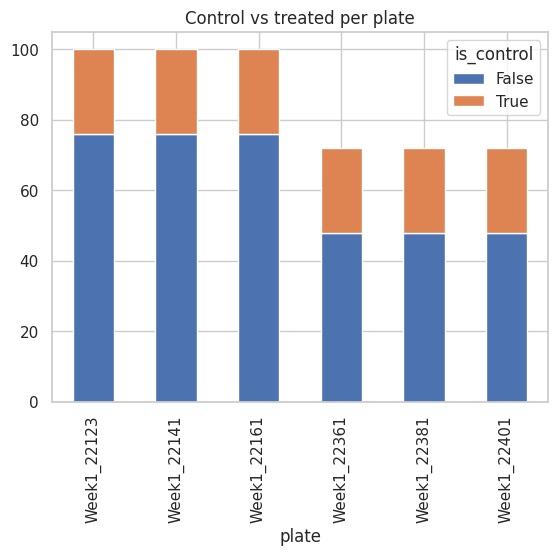

In [22]:
metadata_with_moa.groupby(['plate','is_control']).size().unstack().plot(kind='bar', stacked=True)
plt.title("Control vs treated per plate")

Replicate analysis shows that most compound–concentration conditions contain approximately 12 images, reflecting the intended experimental design. Two conditions, Taxol (0.3 µM) and DMSO (0 µM), are strongly overrepresented with 84 and 72 images respectively, consistent with their role as positive and negative controls included across multiple plates. This imbalance motivates treatment-level aggregation and compound-level cross-validation in downstream modeling.

<Figure size 1000x600 with 0 Axes>

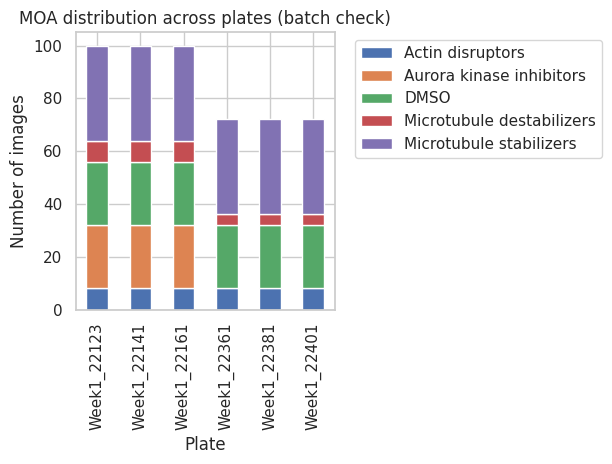

In [23]:
# Plot: MOA vs Plate (batch bias check)
plate_moa = metadata_with_moa.groupby(['plate','moa']).size().unstack(fill_value=0)

plt.figure(figsize=(10,6))
plate_moa.plot(kind='bar', stacked=True)
plt.title("MOA distribution across plates (batch check)")
plt.xlabel("Plate")
plt.ylabel("Number of images")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

Metadata exploration confirms consistent image resolution, expected replicate structure, control/treatment balance, and moderate class imbalance driven by control conditions (Taxol, DMSO). Plate-level visualization suggests [no/severe] batch–MOA confounding.